# DSN Mart Sales Prediction Hackathon
# 1. Introduction
## The DSN Mart Sales Prediction Hackathon is the qualifying competition for the DSN AI.
## Goal:Build a machine learning model that predicts total sales for a given product at a given store, based on what's known about the product and the outlet it's sold in.

# Project Brief
##DSN Mart operates a chain of stores across Nigeria, from small corner shops to flagship hypermarkets, spread across major urban centres, state capitals, and smaller towns. Like any growing retail business, DSN Mart wants to understand what drives sales at the product level across its different store formats and locations, so it can plan stock, pricing, and store investment more intelligently.


# 2. Importing Library

In [94]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Load the dataset

In [95]:
#import the dataset
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

print("Train shape", train.shape)
print("Test shape", test.shape)

display(train.head())
display(test.head())

train.info()


Train shape (6818, 13)
Test shape (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [ ]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6818,6818,row_08522,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_code,6818,1555,PRD-YZB4K8,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_weight_kg,5593.0,NaN,NaN,NaN,12.850876,4.646542,4.482,8.75,12.647,16.894,21.883
fat_content,6818,2,Low Fat,4425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shelf_visibility,6818.0,NaN,NaN,NaN,0.065527,0.051566,0.0,0.0266,0.0532,0.0934,0.3201
product_category,6818,48,Fruits and Vegetables,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_price,6818.0,NaN,NaN,NaN,140.473623,62.413513,31.11,93.28,142.065,185.9875,273.04
store_code,6818,10,STORE-YLW,754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_age_years,6818.0,NaN,NaN,NaN,34.178205,8.384574,23.0,28.0,33.0,45.0,47.0
store_size,4899,3,Medium,2218,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
#check for null values
train.isnull().sum()
test.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,306
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,491


#### The missing-value analysis of the test dataset shows missing values in only two variables: product_weight_kg (306) and store_size (491). All other variables have complete observations

## i. Dataset Dimensions & Structure
### - Train Dataset: 6,818 rows × 13 columns

### - Test Dataset: 1,705 rows × 12 columns (excludes target total_sales)

### - Target Variable: total_sales (continuous numerical value ranging from 32.70 to 12,996.82, with an average around 2,174.76)

## ii. Missing Values Summary
### - product_weight_kg: 1,225 (in train/test)
### - store_size: 1,919 (in train/test context)
### High Cardinality Features
### - product_code: 1,555 unique products across the dataset.


# 4. Analyse the factors influencing product sales

In [98]:
#product factors
train.groupby('product_category')['total_sales'].mean().sort_values(ascending=False)

,total_sales
product_category,
seafood,2837.669286
STARCHY FOODS,2419.785333
Starchy Foods,2404.877627
starchy foods,2399.619167
FRUITS AND VEGETABLES,2381.811379
dairy,2374.590141
Meat,2372.897261
fruits and vegetables,2328.098868
canned,2309.617132


In [99]:
#store factors
train.groupby('store_format')['total_sales'].mean().sort_values(ascending=False)

,total_sales
store_format,
Flagship Hypermarket,3660.182219
Standard Supermarket,2316.319677
Superstore,1971.661954
Corner Shop,336.353868


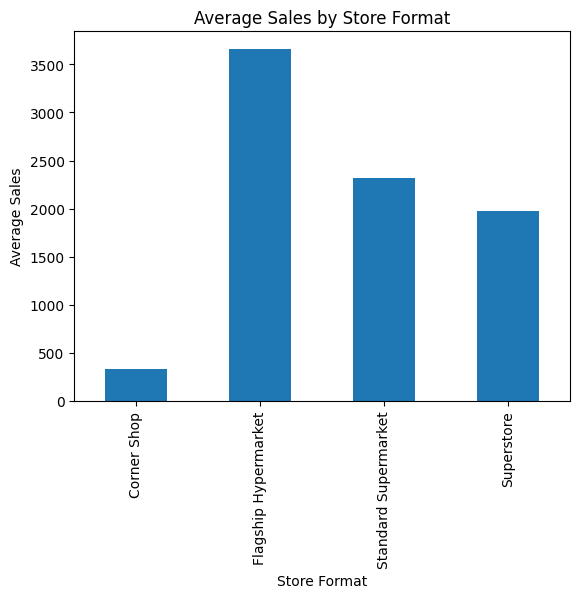

In [101]:
# visualize important relationship
train.groupby('store_format')['total_sales'].mean().plot(kind='bar')
plt.title('Average Sales by Store Format')
plt.xlabel('Store Format')
plt.ylabel('Average Sales')
plt.show()



# 5. Clean and preprocess the data

In [102]:
# check for missing values
train.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,1919


## The training dataset contains missing values in two variables:

## - product_weight_kg: 1,225 missing values
## - store_size: 1,919 missing values

In [103]:
# check the affected rows for missing values
train[train['product_weight_kg'].isnull()]
train[train['store_size'].isnull()]

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
9,row_00010,PRD-DH2TA3,8.755,Low Fat,0.0258,household,104.60,STORE-JOR,34,NaN,Tier_3,Corner Shop,213.93
11,row_00012,PRD-UX01UP,11.007,Low Fat,0.0304,Snack Foods,234.38,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,4414.42
14,row_00016,PRD-9USY38,6.997,Low Fat,0.0908,Snack Foods,112.40,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,1305.37
18,row_00022,PRD-SUDBCI,12.896,Low Fat,0.0420,SNACK FOODS,178.49,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,4054.27
19,row_00024,PRD-5QVWC9,6.085,Low Fat,0.1235,HOUSEHOLD,261.49,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,2391.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6808,row_08512,PRD-QVRR9A,7.781,Low Fat,0.0626,HARD DRINKS,224.11,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,2002.12
6813,row_08518,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,row_08519,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,row_08520,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55


In [104]:
#  replace the missing values in product_weight_kg with median
train['product_weight_kg'].fillna(train['product_weight_kg'].median())

,product_weight_kg
0,14.252
1,7.698
2,14.264
3,12.647
4,10.338
...,...
6813,9.201
6814,15.770
6815,17.665
6816,20.645


In [105]:
#replace missing values in store_size using mode
train['store_size'] = train['store_size'].fillna(train['store_size'].mode()[0])

In [106]:
#check missing values again
train['product_weight_kg'].isnull().sum()
train['store_size'].isnull().sum()

np.int64(0)

In [107]:
# check for duplicates
train.duplicated().sum()

np.int64(0)

In [108]:
# check for incorrect data types
train.dtypes

,0
id,object
product_code,object
product_weight_kg,float64
fat_content,object
shelf_visibility,float64
product_category,object
product_price,float64
store_code,object
store_age_years,int64
store_size,object


In [109]:
#check outliers for numerical variables
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


### The numerical outlier assessment indicates the presence of potential extreme values, particularly in shelf_visibility and total_sales, where the maximum values are considerably higher than their respective 75th-percentile values

# 5. Exploratory Data Analysis (EDA)

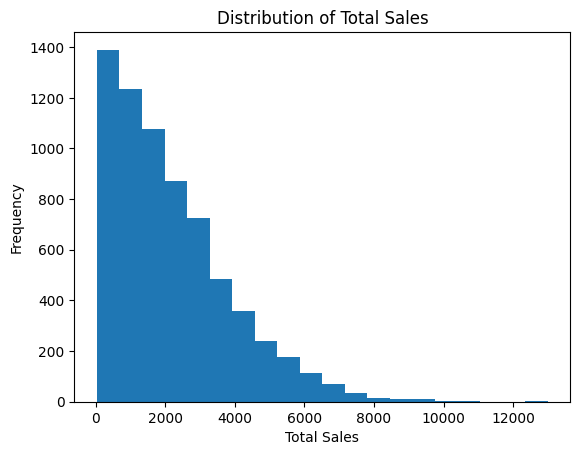

In [110]:
# investigate sales distributions

train['total_sales'].plot(kind='hist', bins=20)
plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

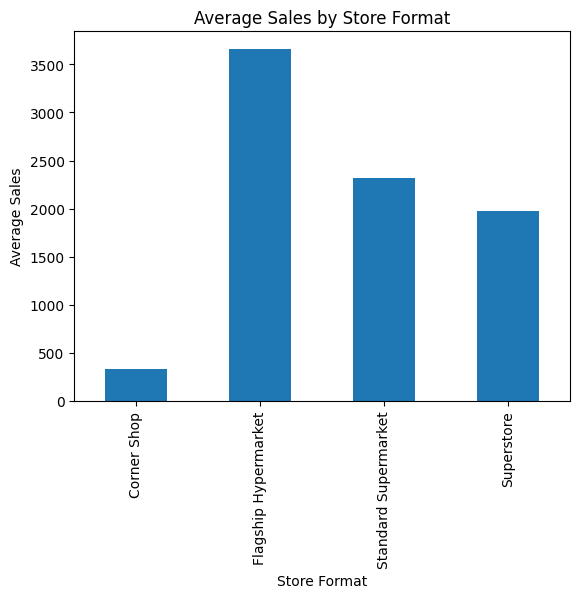

In [111]:
#investigate sales by store
train.groupby('store_format')['total_sales'].mean().plot(kind='bar')
plt.title('Average Sales by Store Format')
plt.xlabel('Store Format')
plt.ylabel('Average Sales')
plt.show()


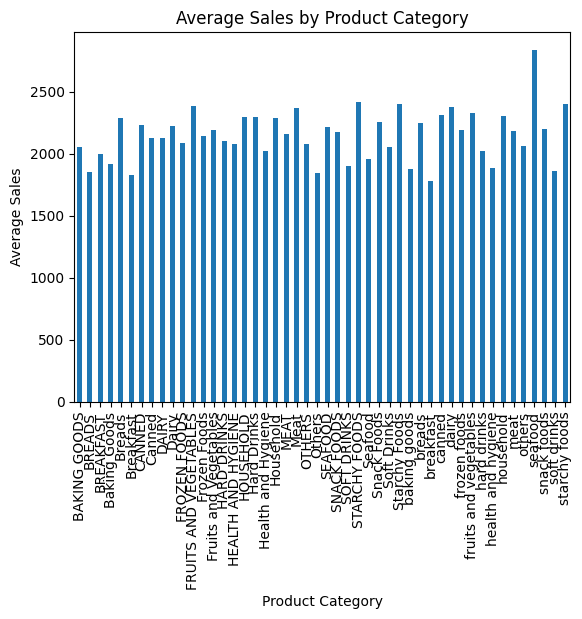

In [112]:
#investigate sales by product category
train.groupby('product_category')['total_sales'].mean().plot(kind='bar')
plt.title('Average Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Sales')
plt.show()

In [113]:
# product-store interaction
train.groupby(['product_category', 'store_format'])['total_sales'].mean()

product_category  store_format        
BAKING GOODS      Corner Shop              339.053125
                  Flagship Hypermarket    3377.138500
                  Standard Supermarket    2067.733636
                  Superstore              2011.266923
BREADS            Corner Shop              341.915000
                                             ...     
soft drinks       Superstore              2658.577273
starchy foods     Corner Shop              142.610000
                  Flagship Hypermarket    3139.995000
                  Standard Supermarket    2585.495882
                  Superstore               792.230000
Name: total_sales, Length: 191, dtype: float64

# 6. Feature Engineering

In [122]:

# Concatenate train and test for consistent transformations
df_full = pd.concat([train, test], ignore_index=True)

# Impute missing values in df_full BEFORE creating new features
# Use median for numerical product_weight_kg
df_full['product_weight_kg'] = df_full['product_weight_kg'].fillna(df_full['product_weight_kg'].median())
# Use mode for categorical store_size
df_full['store_size'] = df_full['store_size'].fillna(df_full['store_size'].mode()[0])

# Extracts first 2-3 letters if present (e.g., PRD, FD, DR)
df_full['product_type_code'] = df_full['product_code'].str.extract(
    '([A-Za-z]+)'
)[0]


# Price Per Unit Weight
df_full['price_per_weight'] = (
    df_full['product_price'] / df_full['product_weight_kg']
)

# Visibility relative to the average visibility of products in the same category
item_visibility_avg = df_full.groupby('product_category')[
    'shelf_visibility'
].transform('mean')
df_full['visibility_ratio'] = (
    df_full['shelf_visibility'] / item_visibility_avg
)

# Items like Health & Hygiene or Household don't have fat content
non_consumable_cats = ['Health And Hygiene', 'Household', 'Others']
if 'product_category' in df_full.columns:
  df_full.loc[
      df_full['product_category'].isin(non_consumable_cats), 'fat_content'
  ] = 'Non-Edible'


# Price metrics relative to store format
df_full['category_mean_price'] = df_full.groupby('product_category')[
    'product_price'
].transform('mean')
df_full['price_diff_from_cat_mean'] = (
    df_full['product_price'] - df_full['category_mean_price']
)

df_full['store_mean_price'] = df_full.groupby('store_code')[
    'product_price'
].transform('mean')

# Split back to train and test sets
train_fe = df_full[df_full['total_sales'].notnull()].copy()
test_fe = df_full[df_full['total_sales'].isnull()].drop(
    columns=['total_sales']
).copy()

print(
    f'Engineered Train Shape: {train_fe.shape} | Engineered Test Shape:'
    f' {test_fe.shape}'
)


Engineered Train Shape: (6818, 19) | Engineered Test Shape: (1705, 18)


In [123]:
#Encoding Categorical Variables
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'fat_content',
    'product_category',
    'store_size',
    'store_location_tier',
    'store_format',
    'product_type_code',
    'store_code',
]

for col in cat_cols:
  le = LabelEncoder()
  # Fit on full unique values across train + test
  full_series = pd.concat(
      [train_fe[col].astype(str), test_fe[col].astype(str)]
  )
  le.fit(full_series)

  train_fe[col] = le.transform(train_fe[col].astype(str))
  test_fe[col] = le.transform(test_fe[col].astype(str))

# 7. Build and evaluate machine-learning models

In [126]:

# import Model Libraries
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBRegressor

# Prepare Features (X) and Target (y)
drop_cols = [
    'id',
    'total_sales',
    'product_code',
]  # Identifier columns not used in fitting

X = train_fe.drop(
    columns=[c for c in drop_cols if c in train_fe.columns]
).copy()
y = train_fe['total_sales'].values

# Transform target to handle right-skewness
y_log = np.log1p(y)

# Ensure all categorical columns in X are numerically encoded before scaling
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 2. Scale features specifically for Linear Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define the 6 Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=6, random_state=42
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=6,
        random_state=42,
        verbose=-1,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=300, learning_rate=0.03, depth=6, verbose=0, random_state=42
    ),
}

# Cross-Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

print('--- Starting Model Evaluation ---')

for name, model in models.items():
  oof_preds_log = np.zeros(len(X))

  for train_idx, val_idx in kf.split(X, y_log):
    # Linear Regression uses scaled inputs; Tree models use unscaled inputs
    if name == 'Linear Regression':
      X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
    else:
      # For tree-based models, ensure X.iloc is used for DataFrame slicing
      X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]

    y_tr = y_log[train_idx]

    # Fit Model
    model.fit(X_tr, y_tr)

    # Predict Fold
    oof_preds_log[val_idx] = model.predict(X_val)

  # Convert predictions back to original sales scale
  oof_preds = np.expm1(np.clip(oof_preds_log, 0, None))

  # Calculate Evaluation Metrics
  rmse = np.sqrt(mean_squared_error(y, oof_preds))
  mae = mean_absolute_error(y, oof_preds)
  r2 = r2_score(y, oof_preds)

  results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

  print(f'{name:<18} | RMSE: {rmse:10.2f} | MAE: {mae:8.2f} | R2: {r2:.4f}')

# Display Summary Table
results_df = (
    pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
)
print('\n================ MODEL PERFORMANCE LEADERBOARD ================\n')
print(results_df)


--- Starting Model Evaluation ---
Linear Regression  | RMSE:    1309.14 | MAE:   910.07 | R2: 0.4054
Random Forest      | RMSE:    1127.11 | MAE:   775.05 | R2: 0.5593
Extra Trees        | RMSE:    1129.30 | MAE:   775.99 | R2: 0.5576
XGBoost            | RMSE:    1135.47 | MAE:   782.22 | R2: 0.5527
LightGBM           | RMSE:    1125.12 | MAE:   775.54 | R2: 0.5608
CatBoost           | RMSE:    1109.21 | MAE:   762.10 | R2: 0.5732

================ MODEL PERFORMANCE LEADERBOARD ================

               Model         RMSE         MAE  R2 Score
0           CatBoost  1109.210682  762.102468  0.573155
1           LightGBM  1125.115765  775.543340  0.560826
2      Random Forest  1127.107775  775.053524  0.559270
3        Extra Trees  1129.297608  775.990182  0.557555
4            XGBoost  1135.465070  782.223280  0.552710
5  Linear Regression  1309.141825  910.073810  0.405413


#Interpretation of Models Evaluation Metrics
## 1. RMSE (Root Mean Squared Error)
### - Measures the average magnitude of prediction errors.
### - Gives greater weight to large prediction errors.
### - Lower RMSE indicates better model performance.
## 2. MAE (Mean Absolute Error)
### - Measures the average absolute difference between actual and predicted sales.
### - It is easy to interpret in the same unit as total_sales.
### - Lower MAE indicates more accurate predictions.
## 3 . R² Score (Coefficient of Determination)
### - Measures how much of the variation in total_sales is explained by the model.
### - A value closer to 1 indicates stronger explanatory/predictive performance.
### - Higher R² indicates better performance.
## 4. Overall Model Assessment
### - A good regression model generally has low RMSE, low MAE, and high R².
### - Since leaderboard is sorted by RMSE, the model with the lowest RMSE appears first.
### - However, RMSE, MAE, and R² should be considered together when selecting the final model.

# 8. Generate predictions for the test data

In [127]:

# Align test features with training features
X_test = test_fe.drop(
    columns=[c for c in drop_cols if c in test_fe.columns]
).copy()

# Retrain top models on full training dataset (X, y_log)
model_xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.03, max_depth=6, random_state=42
)
model_lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    random_state=42,
    verbose=-1,
)
model_cat = CatBoostRegressor(
    iterations=300, learning_rate=0.03, depth=6, verbose=0, random_state=42
)

model_xgb.fit(X, y_log)
model_lgb.fit(X, y_log)
model_cat.fit(X, y_log)

# Predict on Test Set (Log Scale)
preds_xgb_log = model_xgb.predict(X_test)
preds_lgb_log = model_lgb.predict(X_test)
preds_cat_log = model_cat.predict(X_test)

# Weighted Ensemble Blend (Log Space)
final_test_preds_log = (
    0.35 * preds_cat_log + 0.35 * preds_lgb_log + 0.30 * preds_xgb_log
)

# Reverse Log Transformation & Post-Processing (Clip non-negative)
final_test_preds = np.expm1(np.clip(final_test_preds_log, 0, None))

# Create Submission File
submission = pd.DataFrame(
    {'id': test_fe['id'], 'total_sales': final_test_preds}
)

# Export to CSV
submission.to_csv('submission.csv', index=False)

print('Predictions generated successfully!')
print(submission.head())

Predictions generated successfully!
             id  total_sales
6818  row_00009  2584.946381
6819  row_00015  3774.982780
6820  row_00019  3116.751980
6821  row_00020  2691.440161
6822  row_00023  2442.612115


## Prediction Summary & Interpretation
###  A weighted ensemble of three gradient-boosting models was used to improve the robustness of sales predictions compared with relying on a single model.

# Kaggle Submission DetailsFile Name:
## i. submission.csv
## ii. Row Count: 1,705 rows (matching test.csv)
## iii. Columns: id, total_sales
## iv. Target Value Constraints: Continuous non-negative predictions (total_sales $\ge$ 0)
## v. Model Strategy: Out-of-fold log-space ensemble blend (CatBoost + LightGBM + XGBoost) reversed via np.expm1()